In [47]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [48]:
# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting
from cooltools import insulation

In [49]:
resolution = 5000
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")

In [50]:
# doing first for control
windows = [30000, 50000, 100000]
insulation_table = insulation(clr_1, windows, verbose=True)

INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root:Processing region chr7
INFO:root:Processing region chr8
INFO:root:Processing region chr9
INFO:root:Processing region chr10
INFO:root:Processing region chr11
INFO:root:Processing region chr12
INFO:root:Processing region chr13
INFO:root:Processing region chr14
INFO:root:Processing region chr15
INFO:root:Processing region chr16
INFO:root:Processing region chr17
INFO:root:Processing region chr18
INFO:root:Processing region chr19
INFO:root:Processing region chr20
INFO:root:Processing region chr21
INFO:root:Processing region chr22
INFO:root:Processing region chrX
INFO:root:Processing region chrY
INFO:root:Processing region chrM


In [51]:
insulation_table

,chrom,start,end,region,is_bad_bin,log2_insulation_score_30000,n_valid_pixels_30000,log2_insulation_score_50000,n_valid_pixels_50000,log2_insulation_score_100000,n_valid_pixels_100000,boundary_strength_30000,boundary_strength_50000,boundary_strength_100000,is_boundary_30000,is_boundary_50000,is_boundary_100000
0,chr1,0,5000,chr1,True,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,False,False,False
1,chr1,5000,10000,chr1,True,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,False,False,False
2,chr1,10000,15000,chr1,True,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,False,False,False
3,chr1,15000,20000,chr1,True,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,False,False,False
4,chr1,20000,25000,chr1,True,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617664,chrY,57225000,57227415,chrY,True,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,False,False,False
617665,chrM,0,5000,chrM,False,0.075045,2.0,0.075045,2.0,0.075045,2.0,NaN,NaN,NaN,False,False,False
617666,chrM,5000,10000,chrM,False,-0.038070,3.0,-0.038070,3.0,-0.038070,3.0,NaN,NaN,NaN,False,False,False
617667,chrM,10000,15000,chrM,False,-0.038070,3.0,-0.038070,3.0,-0.038070,3.0,NaN,NaN,NaN,False,False,False


In [52]:
first_window_summary =insulation_table.columns[[ str(windows[-1]) in i for i in insulation_table.columns]] # list comprehension -> boolean maskn for windows mentioned earlier

insulation_table[['chrom','start','end','region','is_bad_bin']+list(first_window_summary)].iloc[1000:1010]

,chrom,start,end,region,is_bad_bin,log2_insulation_score_100000,n_valid_pixels_100000,boundary_strength_100000,is_boundary_100000
1000,chr1,5000000,5005000,chr1,False,-0.039567,397.0,NaN,False
1001,chr1,5005000,5010000,chr1,False,-0.054045,397.0,0.014478,False
1002,chr1,5010000,5015000,chr1,False,-0.032601,397.0,NaN,False
1003,chr1,5015000,5020000,chr1,False,-0.021510,397.0,NaN,False
1004,chr1,5020000,5025000,chr1,False,-0.043723,397.0,NaN,False
1005,chr1,5025000,5030000,chr1,False,-0.074226,397.0,NaN,False
1006,chr1,5030000,5035000,chr1,False,-0.090338,397.0,0.068828,False
1007,chr1,5035000,5040000,chr1,False,-0.085801,397.0,NaN,False
1008,chr1,5040000,5045000,chr1,False,-0.088213,397.0,0.002411,False
1009,chr1,5045000,5050000,chr1,False,-0.075685,397.0,NaN,False


In [53]:
bound = [i for i in insulation_table.columns if "is_boundary" in i]
print(bound)

['is_boundary_30000', 'is_boundary_50000', 'is_boundary_100000']


In [54]:
insulation_table[insulation_table["is_boundary_30000"] == True]

for i in bound:
    print(len(insulation_table[insulation_table[i] == True]))

22880
15143
8990


In [55]:
# TADs per chrom
for i in bound:
    print(i)
    print(insulation_table[insulation_table["is_boundary_30000"]].groupby("chrom").size())
    print("next resolution")

is_boundary_30000
chrom
chr1     1880
chr2     1808
chr3     1523
chr4     1333
chr5     1346
chr6     1285
chr7     1162
chr8     1097
chr9      878
chr10    1065
chr11    1060
chr12    1093
chr13     677
chr14     728
chr15     680
chr16     594
chr17     749
chr18     579
chr19     604
chr20     549
chr21     249
chr22     353
chrX     1405
chrY      183
chrM        0
dtype: int64
next resolution
is_boundary_50000
chrom
chr1     1880
chr2     1808
chr3     1523
chr4     1333
chr5     1346
chr6     1285
chr7     1162
chr8     1097
chr9      878
chr10    1065
chr11    1060
chr12    1093
chr13     677
chr14     728
chr15     680
chr16     594
chr17     749
chr18     579
chr19     604
chr20     549
chr21     249
chr22     353
chrX     1405
chrY      183
chrM        0
dtype: int64
next resolution
is_boundary_100000
chrom
chr1     1880
chr2     1808
chr3     1523
chr4     1333
chr5     1346
chr6     1285
chr7     1162
chr8     1097
chr9      878
chr10    1065
chr11    1060
chr12    1093
c

/tmp/ipykernel_1068020/3371521600.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(insulation_table[insulation_table["is_boundary_30000"]].groupby("chrom").size())
/tmp/ipykernel_1068020/3371521600.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(insulation_table[insulation_table["is_boundary_30000"]].groupby("chrom").size())
/tmp/ipykernel_1068020/3371521600.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this war

---

#### plotting - supplement

In [56]:
# Functions to help with plotting
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, *args, **kwargs):
    start_pos_vector = [start+resolution*i for i in range(len(matrix_c)+1)]
    import itertools
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                           start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im

from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

(10500000.0, 13200000.0)

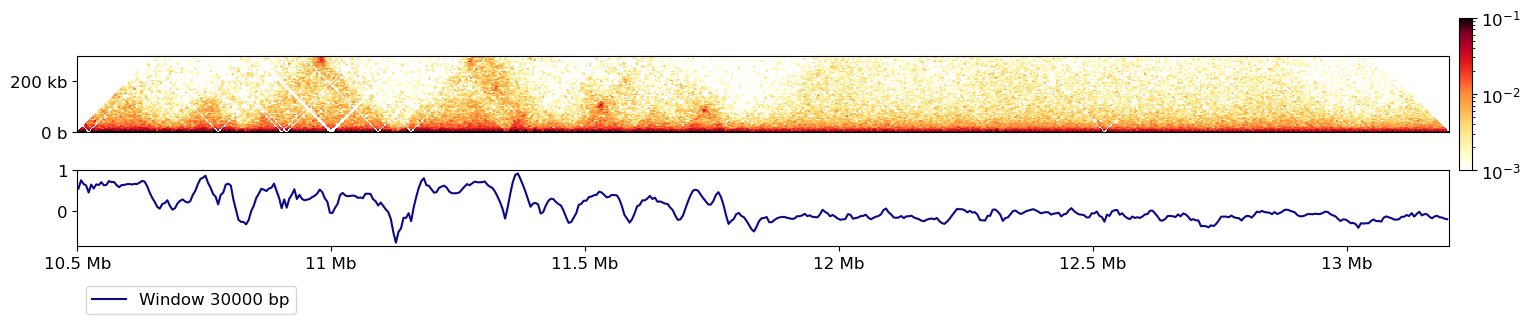

In [57]:
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
plt.rcParams['font.size'] = 12

start = 10_500_000
end = start+ 90*windows[0]
region = ('chr2', start, end)
norm = LogNorm(vmax=0.1, vmin=0.001)
data = clr_1.matrix(balance=True).fetch(region)
f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.set_prop_cycle(plt.cycler("color", plt.cm.plasma(np.linspace(0,1,5))))
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region['log2_insulation_score_'+str(windows[0])],
            label=f'Window {windows[0]} bp')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

In [58]:
windows

[30000, 50000, 100000]

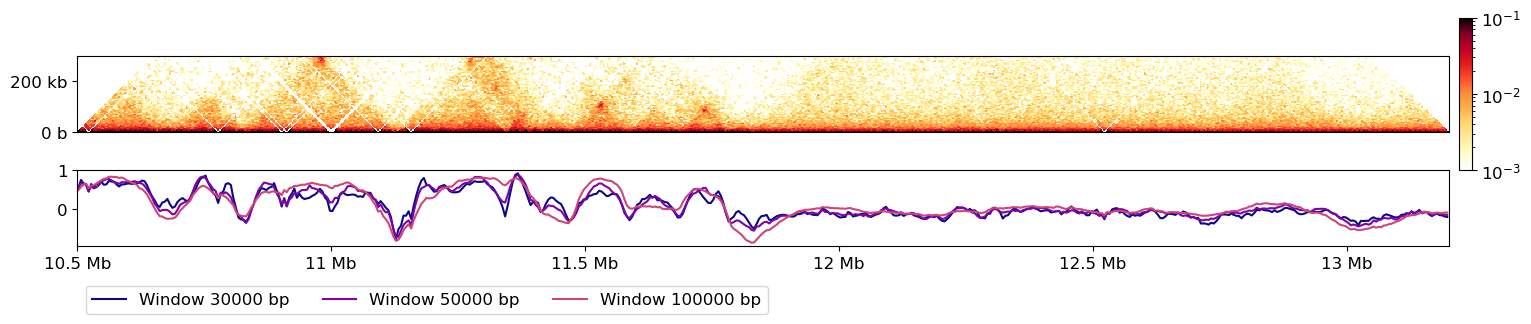

In [59]:
for res in windows[1:]:
    ins_ax.plot(insul_region[['start', 'end']].mean(axis=1), insul_region[f'log2_insulation_score_{res}'], label=f'Window {res} bp')
ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);
f

(10500000.0, 13200000.0)

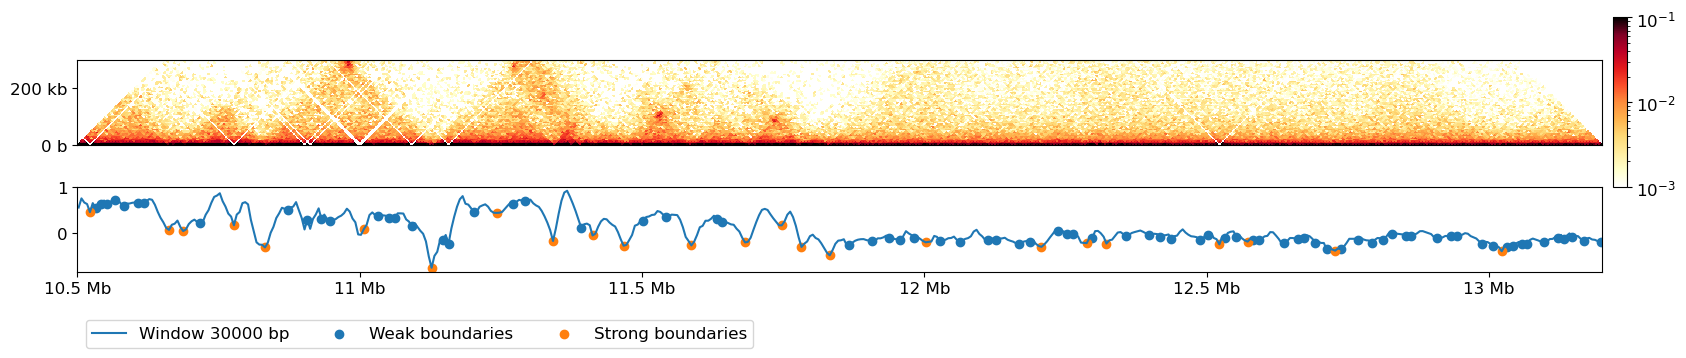

In [60]:
# visually finding TAD boundaries
f, ax = plt.subplots(figsize=(20, 10))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)

ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region[f'log2_insulation_score_{windows[0]}'], label=f'Window {windows[0]} bp')

boundaries = insul_region[~np.isnan(insul_region[f'boundary_strength_{windows[0]}'])]
weak_boundaries = boundaries[~boundaries[f'is_boundary_{windows[0]}']]
strong_boundaries = boundaries[boundaries[f'is_boundary_{windows[0]}']]
ins_ax.scatter(weak_boundaries[['start', 'end']].mean(axis=1),
            weak_boundaries[f'log2_insulation_score_{windows[0]}'], label='Weak boundaries')
ins_ax.scatter(strong_boundaries[['start', 'end']].mean(axis=1),
            strong_boundaries[f'log2_insulation_score_{windows[0]}'], label='Strong boundaries')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])


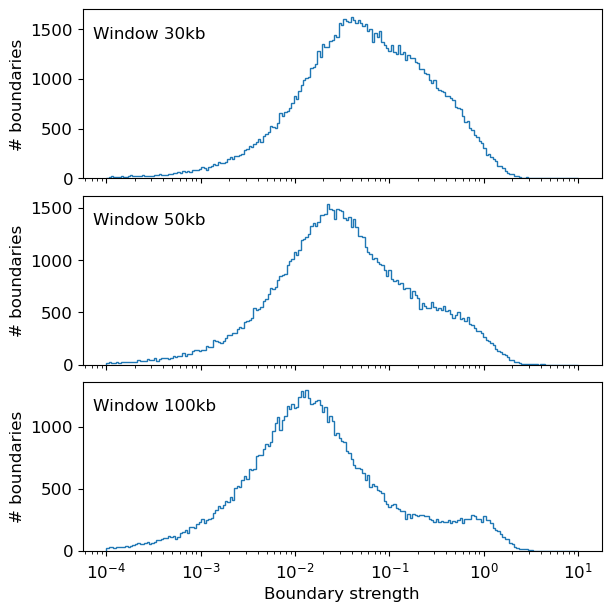

In [61]:
histkwargs = dict(
    bins=10**np.linspace(-4,1,200),
    histtype='step',
    lw=2,
)

f, axs = plt.subplots(len(windows),1, sharex=True, figsize=(6,6), constrained_layout=True)
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table[f'boundary_strength_{w}'],
        **histkwargs
    )
    ax.text(0.02, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength');

# no. of boundaries neg. correlated to window size

[Text(0.5, 0, 'Boundary strength')]

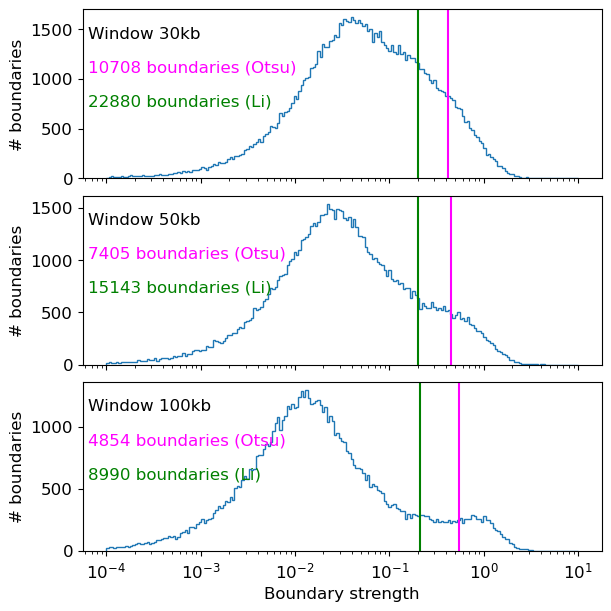

In [62]:
# otsu - conservative, Li - permissive
from skimage.filters import threshold_li, threshold_otsu

f, axs = plt.subplots(len(windows), 1, sharex=True, figsize=(6,6), constrained_layout=True)
thresholds_li = {}
thresholds_otsu = {}
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table[f'boundary_strength_{w}'],
        **histkwargs
    )
    thresholds_li[w] = threshold_li(insulation_table[f'boundary_strength_{w}'].dropna().values)
    thresholds_otsu[w] = threshold_otsu(insulation_table[f'boundary_strength_{w}'].dropna().values)
    n_boundaries_li = (insulation_table[f'boundary_strength_{w}'].dropna()>=thresholds_li[w]).sum()
    n_boundaries_otsu = (insulation_table[f'boundary_strength_{w}'].dropna()>=thresholds_otsu[w]).sum()
    ax.axvline(thresholds_li[w], c='green')
    ax.axvline(thresholds_otsu[w], c='magenta')
    ax.text(0.01, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)
    ax.text(0.01, 0.7,
            f'{n_boundaries_otsu} boundaries (Otsu)',
            c='magenta',
            ha='left',
            va='top',
            transform=ax.transAxes)
    ax.text(0.01, 0.5,
            f'{n_boundaries_li} boundaries (Li)',
            c='green',
            ha='left',
            va='top',
            transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength')

In [63]:
thresholds_otsu[w]

0.5412781663381212

In [64]:
for w in windows:
    col = f"boundary_strength_{w}"
    mask = insulation_table[col].fillna(0) >= thresholds_otsu[w] # mask will have vals. above threshold (here just otsu) which will then be applied to the original dataframe under consideration.
    boundaries_df = insulation_table[mask][["chrom", "start", "end"]].copy()

    # Optional: Add a name and score for BED6
    boundaries_df["name"] = f"TAD_boundary_{w}"
    boundaries_df["score"] = 0

    # Reorder for BED6
    boundaries_df = boundaries_df[["chrom", "start", "end", "name", "score"]]

    print( boundaries_df)
    # Export
    boundaries_df.to_csv(f"cooltools_insul_otsu_boundaries_{w}.bed", sep="\t", header=False, index=False)

       chrom     start       end                name  score
771     chr1   3855000   3860000  TAD_boundary_30000      0
781     chr1   3905000   3910000  TAD_boundary_30000      0
831     chr1   4155000   4160000  TAD_boundary_30000      0
931     chr1   4655000   4660000  TAD_boundary_30000      0
1102    chr1   5510000   5515000  TAD_boundary_30000      0
...      ...       ...       ...                 ...    ...
610503  chrY  21420000  21425000  TAD_boundary_30000      0
610687  chrY  22340000  22345000  TAD_boundary_30000      0
611507  chrY  26440000  26445000  TAD_boundary_30000      0
611546  chrY  26635000  26640000  TAD_boundary_30000      0
617589  chrY  56850000  56855000  TAD_boundary_30000      0

[10708 rows x 5 columns]
       chrom     start       end                name  score
759     chr1   3795000   3800000  TAD_boundary_50000      0
781     chr1   3905000   3910000  TAD_boundary_50000      0
832     chr1   4160000   4165000  TAD_boundary_50000      0
1101    chr1  